# Ordinal Logistic Loss (Cumulative Link Model)

This loss function handles ordinal relationships by modeling the cumulative probability.

Note: the following code and explination are sourced heavily from:
https://hippocampus-garden.com/ordinal_regression/#:~:text=In%20this%20post%2C%20we%20covered%20three%20approaches,and%20multiple%20thresholds%20to%20model%20cumulative%20probabilities

The cumulative probability is modeled as

$P(y <= k) = \sigma(a_k - z)$

The probability of each class is derived as follows, using $P(y = 1)$ as an example, and then generalizing.

$P(y = 1) = \sigma(a_1 - z) - \sigma(a_0 - z)$

Generalizing to:
$P(y = k) = \sigma(a_k - z) - \sigma(a_{k-1} - z), k = 1,...,K - 1$
$P(y = K - 1) = 1 - \sigma(a_{K - 2} - z)$

These probabilities are used to compute the ordinal logistic loss as the negative log likelihood:

$L = - \sum_i logP(y = y_i)$

In [2]:
!git clone https://github.com/nedcut/ML-final.git
%cd ML-final
!pip install coral_pytorch

Cloning into 'ML-final'...
remote: Enumerating objects: 119, done.
remote: Counting objects: 100% (119/119), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 119 (delta 37), reused 63 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (119/119), 11.56 MiB | 4.84 MiB/s, done.
Resolving deltas: 100% (37/37), done.
/content/ML-final


y
0    260
1    161
3    161
2    159
Name: count, dtype: int64
train seasons:  1999-00 through 2016-17 (510 rows)
val seasons:  2017-18 through 2019-20 (90 rows)
test seasons: 2020-21 through 2024-25 (141 rows)
features: 39
x
torch.Size([510, 39])
y
torch.Size([510])


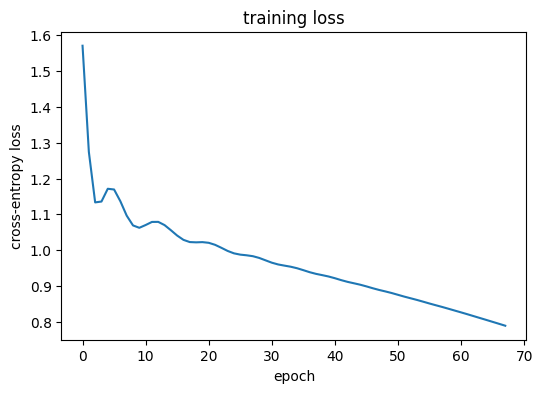

best epoch: 48
stopped epoch: 68
best val loss: 0.9503
saved checkpoint: data/processed/best_ski_mlp.pt
train: accuracy=0.318, macro_f1=0.221, within_one=0.382
 val: accuracy=0.267, macro_f1=0.197, within_one=0.322
test: accuracy=0.411, macro_f1=0.215, within_one=0.504

test confusion matrix
predicted  A  B  C   D
actual                
A          0  0  0   0
B          0  0  0   4
C          0  0  0  13
D          0  0  0  58


In [3]:
from pathlib import Path
import copy
import random
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F


DATA_PATH = Path("data/processed/vt_condition_weather_aligned.csv")
CHECKPOINT_PATH = Path("data/processed/best_ski_mlp.pt")
SEED = 3

TEST_SEASONS = 5
VAL_SEASONS = 3

HIDDEN = 128
LR = 0.01
MAX_EPOCHS = 300
PATIENCE = 20
MIN_DELTA = 1e-5

GRADE_ORDER = ["D", "C", "B", "A"]
GRADE_TO_Y = {grade: i for i, grade in enumerate(GRADE_ORDER)} # D=0, C=1, B=2, A=3
Y_TO_GRADE = {i: grade for grade, i in GRADE_TO_Y.items()}     # 0=D, 1=C, 2=B, 3=A


class SkiMLP(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, HIDDEN),
            nn.ReLU(),
            nn.Linear(HIDDEN, 1),
        )
        self.raw_alpha = nn.Parameter(torch.zeros(3))

    def forward(self, x):
        X = self.net(x)
        X = X.squeeze(-1)
        alpha_sorted = torch.cumsum(F.softplus(self.raw_alpha), dim= 0)
        return X, alpha_sorted

class OrdinalLogLoss(nn.Module):
  def __init__(self, num_classes):
    super().__init__()
    self.num_classes = num_classes

  def forward(self, inputs, target):
    z, alpha = inputs
    K = self.num_classes
    batch_size = z.size(0)

    sig_all = torch.sigmoid(alpha.unsqueeze(1) - z.unsqueeze(0))

    #P(Y= 0)
    p_y0 = sig_all[0]

    #P(Y= 1)
    p_y1 = sig_all[1] - sig_all[0]

    #P(Y = 2)
    p_y2 = sig_all[2] - sig_all[1]

    #P(Y= 3)
    p_y3 = 1.0 - sig_all[2]

    p = torch.empty_like(z)

    mask0 = (target == 0)
    p[mask0] = p_y0[mask0]

    mask1 = (target == 1)
    p[mask1] = p_y1[mask1]

    mask2 = (target == 2)
    p[mask2] = p_y2[mask2]

    mask3 = (target == 3)
    p[mask3] = p_y3[mask3]

    #-log likelihood
    #random error
    epsilon = 1e-12
    nll = -torch.log(p + epsilon)

    return nll.mean()


def make_split(df):
    """split data into train, val, test based on season, using the last seasons for test and val"""
    seasons = sorted(df["season"].unique(), key=lambda s: int(str(s).split("-")[0]))
    test_seasons = seasons[-TEST_SEASONS:]
    val_start = -(TEST_SEASONS + VAL_SEASONS)
    val_seasons = seasons[val_start:-TEST_SEASONS]
    train_seasons = seasons[:val_start]

    train_df = df[df["season"].isin(train_seasons)].reset_index(drop=True)
    val_df = df[df["season"].isin(val_seasons)].reset_index(drop=True)
    test_df = df[df["season"].isin(test_seasons)].reset_index(drop=True)

    print(f"train seasons:  {train_seasons[0]} through {train_seasons[-1]} ({len(train_df)} rows)")
    print(f"val seasons:  {val_seasons[0]} through {val_seasons[-1]} ({len(val_df)} rows)")
    print(f"test seasons: {test_seasons[0]} through {test_seasons[-1]} ({len(test_df)} rows)")
    return train_df, val_df, test_df




def weekly_features(df):
    """select numeric columns that start with 'avg_' or 'best_' and end with '_7d' """
    numeric_cols = [
        c for c in df.columns
        if (c.startswith("avg_") or c.startswith("best_"))
        and pd.api.types.is_numeric_dtype(df[c])
    ]
    return [c for c in numeric_cols if c.endswith("_7d")]


def make_tensors(train_df, val_df, test_df, feature_cols):
    """convert dataframes to tensors, normalizing features based on train__df statistics"""
    train_x = train_df[feature_cols].to_numpy(dtype="float32")
    val_x = val_df[feature_cols].to_numpy(dtype="float32")
    test_x = test_df[feature_cols].to_numpy(dtype="float32")

    mu = train_x.mean(axis=0, keepdims=True)
    sigma = train_x.std(axis=0, keepdims=True)
    sigma[sigma == 0] = 1

    train_x = (train_x - mu) / sigma
    val_x = (val_x - mu) / sigma
    test_x = (test_x - mu) / sigma

    return (
        torch.tensor(train_x, dtype=torch.float32),
        torch.tensor(train_df["y"].to_numpy(), dtype=torch.long),
        torch.tensor(val_x, dtype=torch.float32),
        torch.tensor(val_df["y"].to_numpy(), dtype=torch.long),
        torch.tensor(test_x, dtype=torch.float32),
        torch.tensor(test_df["y"].to_numpy(), dtype=torch.long),
    )


def macro_f1(preds, y):
    scores = []
    for cls in range(4):
        tp = ((preds == cls) & (y == cls)).sum().item()
        fp = ((preds == cls) & (y != cls)).sum().item()
        fn = ((preds != cls) & (y == cls)).sum().item()
        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        scores.append(2 * precision * recall / (precision + recall) if precision + recall else 0.0)
    return float(np.mean(scores))


def evaluate(model, x, y):
    model.eval()
    with torch.no_grad():
      z_test, alpha_test = model(x)
      #print(f"z_test: {z_test}")
      #print(f"alpha_test: {alpha_test}")

      sig_all = torch.sigmoid(alpha_test.unsqueeze(1) - z_test.unsqueeze(0))

      # p(Y=0) = σ(alpha_0 - z)
      p_y0 = sig_all[0].unsqueeze(1)

      # p(Y = 1) = σ(alpha_1 - z) - σ(alpha_0 - z)
      p_y1 = sig_all[1] - sig_all[0].unsqueeze(1)

      # p(Y = 2) = σ(alpha_2 - z) - σ(alpha_1 - z)
      p_y2 = sig_all[2] - sig_all[1].unsqueeze(1)

      # p(Y = 3) = 1 - σ(alpha_2 - z)
      p_y3 = 1 - sig_all[2].unsqueeze(1)

      p_all = torch.cat([p_y0, p_y1, p_y2, p_y3], dim = 1)
      preds = torch.argmax(p_all, dim = 1)

    return {
        "accuracy": (preds == y).float().mean().item(),
        # if the target is only 1 grade away from prediction (eg predicted B but it's actually A)
        "within_one": ((preds - y).abs() <= 1).float().mean().item(),
        "macro_f1": macro_f1(preds, y),
        "preds": preds,
    }


def train(model, x_train, y_train, x_val, y_val):
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    best_val_loss = float("inf")
    best_epoch = 0
    best_state = copy.deepcopy(model.state_dict())
    bad_checks = 0 # number of consecutive epochs without improvement
    criterion = OrdinalLogLoss(4)
    loss_history = []


    #figure out how to get scores from the model
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train() # need to set train mode for dropout to work
        opt.zero_grad()
        if (epoch == 1) :
            print("x")
            print(x_train.size())
            print("y")
            print(y_train.size())
        loss = criterion(model(x_train), y_train)
        loss_history.append(loss.detach())
        loss.backward()
        opt.step()

        model.eval() # back to eval mode for validation (no dropout, no grad)
        with torch.no_grad():
            val_loss = criterion(model(x_val), y_val)

        if val_loss < best_val_loss - MIN_DELTA:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            bad_checks = 0
        else:
            bad_checks += 1

        if bad_checks >= PATIENCE:
            break # stop early

    model.load_state_dict(best_state)
    return best_epoch, epoch, best_val_loss, loss_history


def print_metrics(name, metrics):
    print(
        f"{name:>4}: "
        f"accuracy={metrics['accuracy']:.3f}, "
        f"macro_f1={metrics['macro_f1']:.3f}, "
        f"within_one={metrics['within_one']:.3f}"
    )


def save_checkpoint(model, feature_cols, best_epoch, stopped_epoch, best_val_loss):
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "feature_cols": feature_cols,
        "grade_order": GRADE_ORDER,
        "config": {
            "hidden": HIDDEN,
            "lr": LR,
            "seed": SEED,
            "test_seasons": TEST_SEASONS,
            "val_seasons": VAL_SEASONS,
            "best_epoch": best_epoch,
            "stopped_epoch": stopped_epoch,
            "best_val_loss": best_val_loss,
        },
    }
    CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)
    torch.save(checkpoint, CHECKPOINT_PATH)
    print(f"saved checkpoint: {CHECKPOINT_PATH}")


if __name__ == "__main__":
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    df = pd.read_csv(DATA_PATH)
    df["y"] = df["grade"].map(GRADE_TO_Y)
    print(df["y"].value_counts())

    train_df, val_df, test_df = make_split(df)
    feature_cols = weekly_features(df)
    print(f"features: {len(feature_cols)}")

    x_train, y_train, x_val, y_val, x_test, y_test = make_tensors(
        train_df,
        val_df,
        test_df,
        feature_cols,
    )

    model = SkiMLP(x_train.shape[1])
    best_epoch, stopped_epoch, best_val_loss, loss = train(model, x_train, y_train, x_val, y_val)

    #print(type(loss))
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(loss)
    ax.set(xlabel="epoch", ylabel="cross-entropy loss", title="training loss")
    plt.show()

    print(f"best epoch: {best_epoch}")
    print(f"stopped epoch: {stopped_epoch}")
    print(f"best val loss: {best_val_loss:.4f}")
    save_checkpoint(model, feature_cols, best_epoch, stopped_epoch, best_val_loss)

    train_metrics = evaluate(model, x_train, y_train)
    val_metrics = evaluate(model, x_val, y_val)
    test_metrics = evaluate(model, x_test, y_test)

    print_metrics("train", train_metrics)
    print_metrics("val", val_metrics)
    print_metrics("test", test_metrics)

    confusion = pd.crosstab(
        pd.Series(test_df["y"].map(Y_TO_GRADE), name="actual"),
        pd.Series(pd.Series(test_metrics["preds"].numpy()).map(Y_TO_GRADE), name="predicted"),
    ).reindex(index=["A", "B", "C", "D"], columns=["A", "B", "C", "D"], fill_value=0)
    print("\ntest confusion matrix")
    print(confusion)

Overpredicting D because of the class imbalance, will potentially talk to Phil about this!